## Phase 4: Statistical Analysis

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [3]:
df = pd.read_csv(r"US_Accidents_Cleaned.csv")
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hour,Year,Night_Flag,Bad_Weather_Flag,Road_Type
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,Night,Night,Night,Night,5,2016,1,1,Highway
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,Night,Night,Night,Day,6,2016,1,1,Other
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,Night,Night,Day,Day,6,2016,1,0,Urban
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,Night,Day,Day,Day,7,2016,0,0,Highway
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,Day,Day,Day,Day,7,2016,0,0,Other


In [4]:
print(df.columns)

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way',
       'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
       'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Hour',
       'Year', 'Night_Flag', 'Bad_Weather_Flag', 'Road_Type'],
      dtype='object')


In [5]:
print(df['Road_Type'].value_counts())

Road_Type
Other       99030
Highway     51080
Urban       49856
Junction       34
Name: count, dtype: int64


In [6]:
highway = df[df['Road_Type'] == 'Highway']['Severity']
urban = df[df['Road_Type'] == 'Urban']['Severity']
junction = df[df['Road_Type'] == 'Junction']['Severity']
other = df[df['Road_Type'] == 'Other']['Severity']

In [7]:
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(highway, urban, junction, other)
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 19128.22357156086
p-value: 0.0


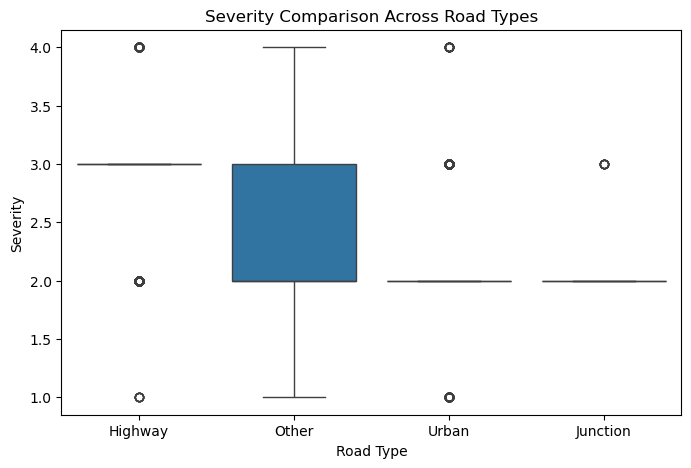

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Road_Type', y='Severity', data=df)

plt.title("Severity Comparison Across Road Types")
plt.xlabel("Road Type")
plt.ylabel("Severity")

plt.show()

### Anova test
The ANOVA test was used to compare accident severity across different road types such as Highway, Urban, Junction, and Other.

The calculated F-statistic is 19128.22 and the p-value is 0.0.

Since the p-value is less than the significance level of 0.05, we reject the null hypothesis.

This indicates that there is a statistically significant difference in accident severity across different road types.

Therefore, road type plays an important role in determining the severity of road accidents.

In [9]:
from scipy.stats import chi2_contingency

In [10]:
contingency_table = pd.crosstab(df['Road_Type'], df['Bad_Weather_Flag'])
print(contingency_table)

Bad_Weather_Flag      0     1
Road_Type                    
Highway           47719  3361
Junction             34     0
Other             93430  5600
Urban             46610  3246


In [11]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square value:", chi2)
print("p-value:", p_value)

Chi-square value: 71.64640038060088
p-value: 1.8952156341569625e-15


### Insight of chi square test

The Chi-square test was used to analyze the relationship between road type and bad weather accidents.

The calculated Chi-square value is 71.65 and the p-value is 1.895e-15.

Since the p-value is less than the significance level of 0.05, we reject the null hypothesis.

This indicates that there is a statistically significant association between road type and bad weather accidents.

Therefore, bad weather accidents occur differently across different road types.

In [12]:
risk_factors = df[['Severity',
                   'Visibility(mi)',
                   'Wind_Speed(mph)',
                   'Temperature(F)']]
risk_factors.head()

,Severity,Visibility(mi),Wind_Speed(mph),Temperature(F)
0,3,10.0,NaN,36.9
1,2,10.0,NaN,37.9
2,2,10.0,3.5,36.0
3,3,9.0,4.6,35.1
4,2,6.0,3.5,36.0


In [13]:
correlation_matrix = risk_factors.corr()

print(correlation_matrix)

                 Severity  Visibility(mi)  Wind_Speed(mph)  Temperature(F)
Severity         1.000000       -0.005052        -0.010692        0.018530
Visibility(mi)  -0.005052        1.000000         0.002072        0.247338
Wind_Speed(mph) -0.010692        0.002072         1.000000       -0.036291
Temperature(F)   0.018530        0.247338        -0.036291        1.000000


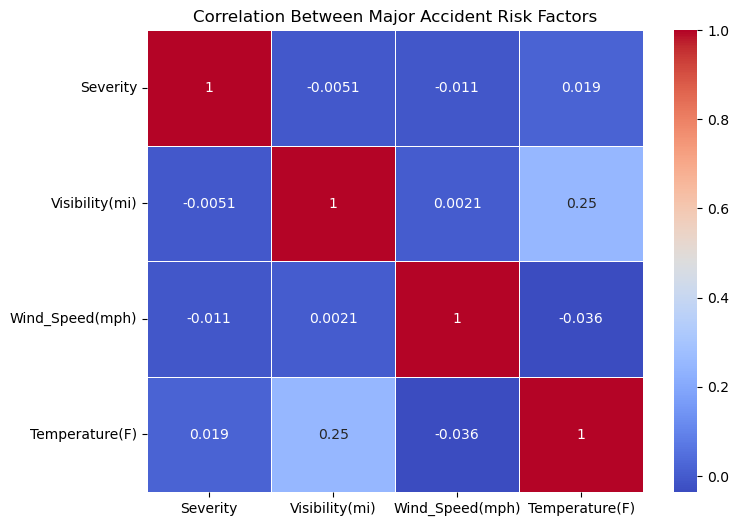

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Between Major Accident Risk Factors")

plt.show()

### Correlation Analysis

A correlation analysis was performed to understand the relationships between major accident risk factors including severity, visibility, wind speed and temperature.

The correlation matrix and heatmap show the strength and direction of relationships between these variables.

However, most correlations are relatively weak, indicating that accident severity is influenced by multiple factors rather than a single variable.

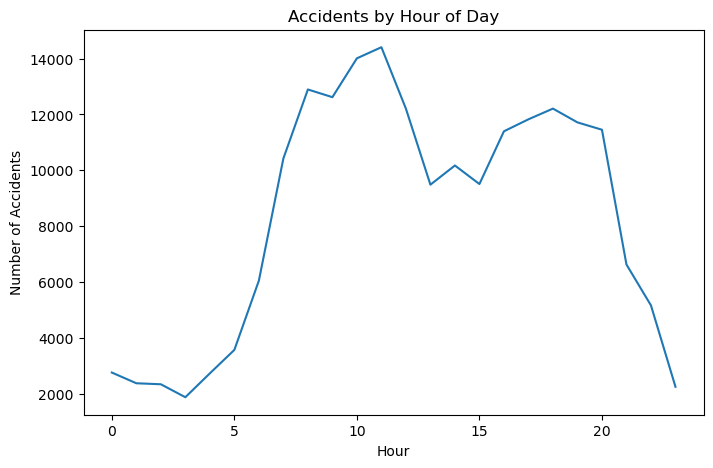

In [34]:
import matplotlib.pyplot as plt

hour_counts = df.groupby("Hour")["Severity"].count()

plt.figure(figsize=(8,5))
hour_counts.plot(kind="line")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

### Temporal Analysis Insights 
The temporal analysis shows that accident frequency varies significantly throughout the day. Accident counts are lowest during early morning hours (1–5 AM) when traffic volume is minimal. The number of accidents increases sharply during the morning commuting period (7–10 AM) and reaches its peak around late morning. A secondary peak occurs during evening commuting hours (4–7 PM), indicating that traffic congestion during rush hours contributes to higher accident occurrence.

### Statistical Insights Summary

• The ANOVA test showed that accident severity differs significantly across different road types. This indicates that certain road categories such as highways or urban roads may experience more severe accidents.

• The Chi-square test revealed a significant association between road type and bad weather accidents. This suggests that weather conditions impact accident occurrences differently depending on the type of road.

• Correlation analysis between environmental variables showed relationships between factors such as visibility, precipitation, wind speed, and accident severity.

• The temporal analysis shows that accident frequency varies significantly throughout the day, mostly during the rush hours.

• Overall, the statistical analysis suggests that both road type and environmental conditions play an important role in influencing road accident severity.




## Phase 5: Behavioral Road Risk Clustering

In [15]:
import pandas as pd

risk_table = pd.read_csv("risk_table_scaled.csv", index_col=0)
risk_table

,Frequency,Severity,Weather,Night,Visibility,Risk_Index
Road_Type,,,,,,
Highway,0.515637,1.00000,1.000000,0.847078,0.676486,0.823620
Junction,0.000000,0.00499,0.000000,1.000000,1.000000,0.251746
Other,1.000000,0.10906,0.859416,0.606464,0.000000,0.508053
Urban,0.503273,0.00000,0.989495,0.000000,0.570483,0.331291


In [16]:
features = risk_table.drop(columns=["Risk_Index"])
features

,Frequency,Severity,Weather,Night,Visibility
Road_Type,,,,,
Highway,0.515637,1.00000,1.000000,0.847078,0.676486
Junction,0.000000,0.00499,0.000000,1.000000,1.000000
Other,1.000000,0.10906,0.859416,0.606464,0.000000
Urban,0.503273,0.00000,0.989495,0.000000,0.570483


In [17]:
X = features.values
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)

risk_table["Cluster"] = kmeans.fit_predict(X)

risk_table

C:\Users\Rishabh Pandey\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Frequency,Severity,Weather,Night,Visibility,Risk_Index,Cluster
Road_Type,,,,,,,
Highway,0.515637,1.00000,1.000000,0.847078,0.676486,0.823620,1
Junction,0.000000,0.00499,0.000000,1.000000,1.000000,0.251746,0
Other,1.000000,0.10906,0.859416,0.606464,0.000000,0.508053,1
Urban,0.503273,0.00000,0.989495,0.000000,0.570483,0.331291,1


In [18]:
cluster_summary = risk_table.groupby("Cluster").mean()
cluster_summary

,Frequency,Severity,Weather,Night,Visibility,Risk_Index
Cluster,,,,,,
0,0.00000,0.004990,0.000000,1.000000,1.000000,0.251746
1,0.67297,0.369687,0.949637,0.484514,0.415656,0.554321


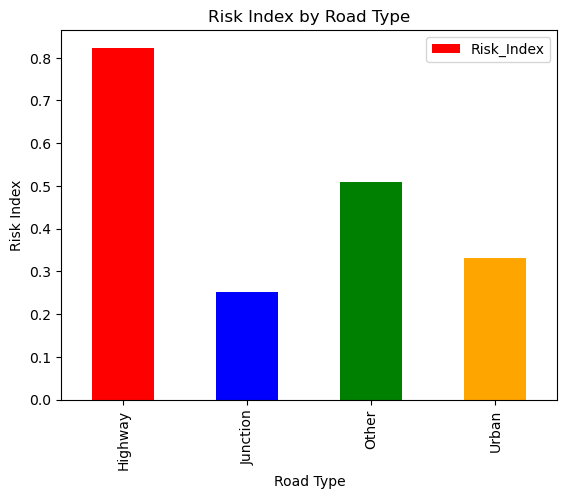

In [19]:
import matplotlib.pyplot as plt

risk_table.reset_index().plot(
    x="Road_Type",
    y="Risk_Index",
    kind="bar",
    color=["red","blue","green","orange"]
)

plt.title("Risk Index by Road Type")
plt.ylabel("Risk Index")
plt.xlabel("Road Type")

plt.show()

In [20]:
risk_table.to_csv("road_clusters.csv")

### Cluster Interpretation

Cluster 0 represents road environments where accidents are strongly associated with nighttime conditions and reduced visibility. Junction roads fall into this cluster, indicating higher vulnerability during night driving.

Cluster 1 represents general accident risk environments where multiple factors such as weather, visibility, and accident frequency contribute collectively to accident occurrence. Highway, urban, and other road types fall within this cluster.

## Phase 6: Accident Risk Prediction Model

In [21]:
df["High_Risk"] = (df["Severity"] >= 3).astype(int)

features = df[['Visibility(mi)',
               'Wind_Speed(mph)',
               'Temperature(F)',
               'Humidity(%)',
               'Pressure(in)',
               'Night_Flag',
               'Bad_Weather_Flag']]

target = df["High_Risk"]

features.head()

,Visibility(mi),Wind_Speed(mph),Temperature(F),Humidity(%),Pressure(in),Night_Flag,Bad_Weather_Flag
0,10.0,NaN,36.9,91.0,29.68,1,1
1,10.0,NaN,37.9,100.0,29.65,1,1
2,10.0,3.5,36.0,100.0,29.67,1,0
3,9.0,4.6,35.1,96.0,29.64,0,0
4,6.0,3.5,36.0,89.0,29.65,0,0


In [26]:
features = features.fillna(features.mean())
features

,Visibility(mi),Wind_Speed(mph),Temperature(F),Humidity(%),Pressure(in),Night_Flag,Bad_Weather_Flag
0,10.000000,8.512051,36.9,91.0,29.68,1,1
1,10.000000,8.512051,37.9,100.0,29.65,1,1
2,10.000000,3.500000,36.0,100.0,29.67,1,0
3,9.000000,4.600000,35.1,96.0,29.64,0,0
4,6.000000,3.500000,36.0,89.0,29.65,0,0
...,...,...,...,...,...,...,...
199995,10.000000,12.700000,52.0,89.0,30.08,1,0
199996,9.281449,6.900000,51.8,88.0,30.42,1,0
199997,10.000000,5.800000,54.0,83.0,30.11,1,0
199998,10.000000,12.700000,48.0,93.0,30.12,1,0


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.609525


In [30]:
model.predict_proba(X_test[:1])

array([[0.29391667, 0.70608333]])

In [32]:
importance=pd.Series(model.feature_importances_,index=features.columns)
importance.sort_values(ascending=False)

Temperature(F)      0.277135
Pressure(in)        0.275059
Humidity(%)         0.248325
Wind_Speed(mph)     0.149277
Visibility(mi)      0.040049
Night_Flag          0.005326
Bad_Weather_Flag    0.004830
dtype: float64

In [33]:
import pickle
pickle.dump(model,open("risk_prediction_model.pk1","wb"))